# TFT Data Exploration — Electricity-style Pipeline (Cycle 2)

This notebook validates the `ElectricityDataModule` output:
- Batch shapes match TFT input requirements
- Value ranges are reasonable (scaled data)
- Temporal features are correctly encoded
- No data leakage across splits

In [1]:
import sys
sys.path.insert(0, '..')

import logging
logging.basicConfig(level=logging.INFO)

import numpy as np
import matplotlib.pyplot as plt
from src.data import ElectricityDataModule

## 1. Initialize Data Module and Load a Batch

In [2]:
dm = ElectricityDataModule(
    tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META'],
    lookback=168,
    horizon=24,
    batch_size=64,
)
dm.setup()
print('Split info:', dm.split_info)

past, future, static, targets = dm.get_sample_batch()
print(f'\npast_inputs shape:         {past.shape}')
print(f'known_future_inputs shape: {future.shape}')
print(f'static_inputs shape:       {static.shape}')
print(f'targets shape:             {targets.shape}')

INFO:src.data:Fetching AAPL from https://ai.1s.xyz/api/data/ohlcv?ticker=AAPL&interval=1h&period=2y


INFO:src.data:Fetching MSFT from https://ai.1s.xyz/api/data/ohlcv?ticker=MSFT&interval=1h&period=2y


INFO:src.data:Fetching GOOGL from https://ai.1s.xyz/api/data/ohlcv?ticker=GOOGL&interval=1h&period=2y


INFO:src.data:Fetching AMZN from https://ai.1s.xyz/api/data/ohlcv?ticker=AMZN&interval=1h&period=2y


INFO:src.data:Fetching NVDA from https://ai.1s.xyz/api/data/ohlcv?ticker=NVDA&interval=1h&period=2y


INFO:src.data:Fetching META from https://ai.1s.xyz/api/data/ohlcv?ticker=META&interval=1h&period=2y


INFO:src.data:Data prepared: train=13440, val=1980, test=1986


Split info: {'train_size': 13440, 'val_size': 1980, 'test_size': 1986, 'n_entities': 6, 'lookback': 168, 'horizon': 24}

past_inputs shape:         torch.Size([64, 168, 6])
known_future_inputs shape: torch.Size([64, 24, 4])
static_inputs shape:       torch.Size([64, 1])
targets shape:             torch.Size([64, 24])


/home/rw/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 2. Shape Verification

Expected shapes:
- `past_inputs`: (batch_size, lookback=168, n_past_features=6)
- `known_future_inputs`: (batch_size, horizon=24, n_known_features=4)
- `static_inputs`: (batch_size, 1)
- `targets`: (batch_size, horizon=24)

In [3]:
assert past.shape == (64, 168, 6), f'Unexpected past shape: {past.shape}'
assert future.shape == (64, 24, 4), f'Unexpected future shape: {future.shape}'
assert static.shape == (64, 1), f'Unexpected static shape: {static.shape}'
assert targets.shape == (64, 24), f'Unexpected targets shape: {targets.shape}'
print('All shape assertions passed!')

All shape assertions passed!


## 3. Value Range Analysis

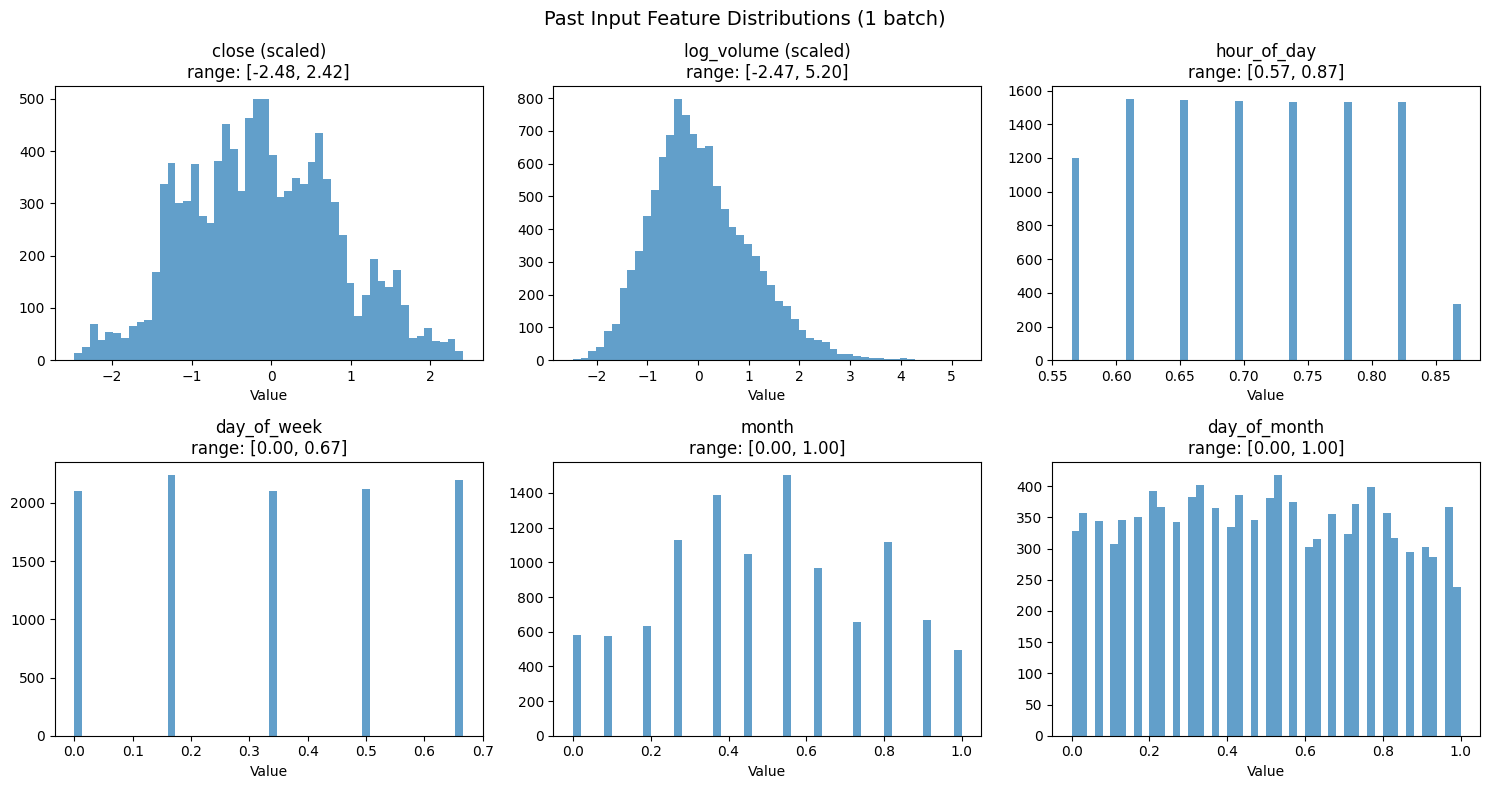

In [4]:
feature_names_past = ['close (scaled)', 'log_volume (scaled)',
                      'hour_of_day', 'day_of_week', 'month', 'day_of_month']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (ax, name) in enumerate(zip(axes.flat, feature_names_past)):
    vals = past[:, :, i].numpy().flatten()
    ax.hist(vals, bins=50, alpha=0.7)
    ax.set_title(f'{name}\nrange: [{vals.min():.2f}, {vals.max():.2f}]')
    ax.set_xlabel('Value')
plt.suptitle('Past Input Feature Distributions (1 batch)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/cycle_2/past_features_dist.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Sample Sequence Visualization

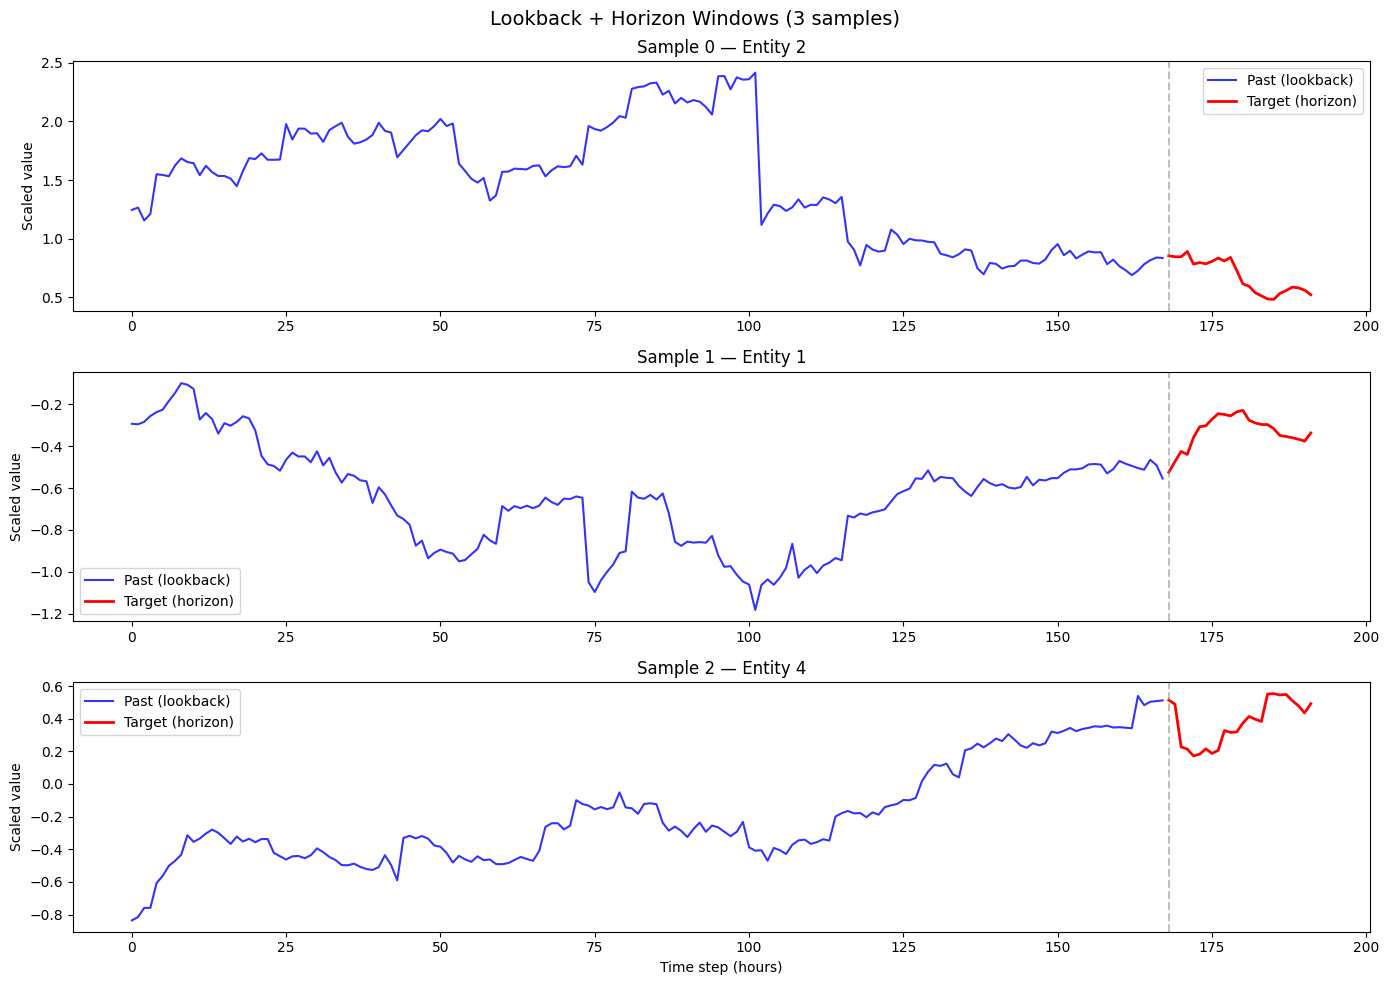

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for sample_idx in range(3):
    ax = axes[sample_idx]
    eid = static[sample_idx, 0].item()
    
    # Past close values
    past_close = past[sample_idx, :, 0].numpy()
    # Target values
    tgt = targets[sample_idx].numpy()
    
    x_past = np.arange(len(past_close))
    x_future = np.arange(len(past_close), len(past_close) + len(tgt))
    
    ax.plot(x_past, past_close, 'b-', label='Past (lookback)', alpha=0.8)
    ax.plot(x_future, tgt, 'r-', label='Target (horizon)', linewidth=2)
    ax.axvline(x=len(past_close), color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'Sample {sample_idx} — Entity {eid}')
    ax.legend()
    ax.set_ylabel('Scaled value')

axes[-1].set_xlabel('Time step (hours)')
plt.suptitle('Lookback + Horizon Windows (3 samples)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/cycle_2/sample_sequences.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Known Future Inputs (Temporal Features)

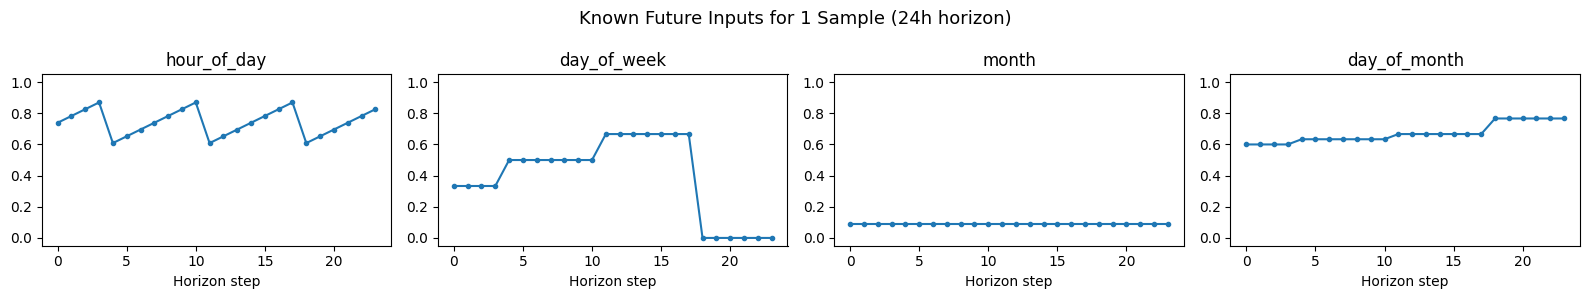

In [6]:
temporal_names = ['hour_of_day', 'day_of_week', 'month', 'day_of_month']

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
sample = future[0].numpy()  # (24, 4)
for i, (ax, name) in enumerate(zip(axes, temporal_names)):
    ax.plot(sample[:, i], 'o-', markersize=3)
    ax.set_title(name)
    ax.set_xlabel('Horizon step')
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Known Future Inputs for 1 Sample (24h horizon)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/cycle_2/future_inputs.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Data Split Summary & Leakage Check

In [7]:
print('Dataset sizes:')
print(f'  Train: {len(dm.train_dataset)} samples')
print(f'  Val:   {len(dm.val_dataset)} samples')
print(f'  Test:  {len(dm.test_dataset)} samples')
print(f'  Total: {len(dm.train_dataset) + len(dm.val_dataset) + len(dm.test_dataset)} samples')
print(f'\nEntities: {dm.split_info["n_entities"]}')
print(f'Lookback: {dm.split_info["lookback"]} hours')
print(f'Horizon:  {dm.split_info["horizon"]} hours')

# Verify no NaN values
for name, ds in [('train', dm.train_dataset), ('val', dm.val_dataset), ('test', dm.test_dataset)]:
    has_nan = (
        ds.past_inputs.isnan().any().item() or
        ds.known_future_inputs.isnan().any().item() or
        ds.targets.isnan().any().item()
    )
    print(f'{name}: NaN present = {has_nan}')

print('\nAll checks passed!')

Dataset sizes:
  Train: 13440 samples
  Val:   1980 samples
  Test:  1986 samples
  Total: 17406 samples

Entities: 6
Lookback: 168 hours
Horizon:  24 hours
train: NaN present = False
val: NaN present = False
test: NaN present = False

All checks passed!
